In [3]:
import os
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

load_dotenv(encoding='utf-8')

engine = create_engine(f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}")

with engine.connect() as conn:
    print("Соединение установлено.")

Соединение установлено.


In [7]:
with engine.connect() as conn:
    df_cohort = pd.read_sql(text("""
        WITH first_purchase AS (
            -- Находим месяц первой покупки каждого клиента
            SELECT 
                "Customer ID",
                DATE_TRUNC('month', MIN("InvoiceDate"))::date as cohort_month
            FROM transactions
            GROUP BY "Customer ID"
        ),
        transactions_with_cohort AS (
            -- Присоединяем когорту к каждой транзакции
            SELECT 
                t."Customer ID",
                DATE_TRUNC('month', t."InvoiceDate")::date as transaction_month,
                fp.cohort_month,
                -- Номер периода: сколько месяцев прошло с первой покупки
                (DATE_PART('year', t."InvoiceDate") - 
                 DATE_PART('year', fp.cohort_month::timestamp)) * 12 +
                (DATE_PART('month', t."InvoiceDate") - 
                 DATE_PART('month', fp.cohort_month::timestamp)) as period_number
            FROM transactions t
            JOIN first_purchase fp ON t."Customer ID" = fp."Customer ID"
        )
        SELECT 
            cohort_month,
            period_number,
            COUNT(DISTINCT "Customer ID") as customers
        FROM transactions_with_cohort
        GROUP BY cohort_month, period_number
        ORDER BY cohort_month, period_number
    """), conn)

print(df_cohort.shape)
print(df_cohort.head(20))

(325, 3)
   cohort_month  period_number  customers
0    2009-12-01            0.0        952
1    2009-12-01            1.0        336
2    2009-12-01            2.0        317
3    2009-12-01            3.0        405
4    2009-12-01            4.0        360
5    2009-12-01            5.0        342
6    2009-12-01            6.0        359
7    2009-12-01            7.0        327
8    2009-12-01            8.0        321
9    2009-12-01            9.0        344
10   2009-12-01           10.0        401
11   2009-12-01           11.0        472
12   2009-12-01           12.0        358
13   2009-12-01           13.0        269
14   2009-12-01           14.0        232
15   2009-12-01           15.0        288
16   2009-12-01           16.0        250
17   2009-12-01           17.0        288
18   2009-12-01           18.0        270
19   2009-12-01           19.0        246
20   2009-12-01           20.0        242
21   2009-12-01           21.0        298
22   2009-12-01          

In [8]:
# Pivot таблица — строки когорты, колонки периоды
cohort_pivot = df_cohort.pivot_table(
    index='cohort_month',
    columns='period_number',
    values='customers'
)

# Считаем retention в процентах
# Делим каждую строку на значение периода 0 (первый месяц)
cohort_size = cohort_pivot[0]  # количество клиентов в когорте
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100
retention_matrix = retention_matrix.round(1)

print(retention_matrix.iloc[:5, :6])

period_number    0.0   1.0   2.0   3.0   4.0   5.0
cohort_month                                      
2009-12-01     100.0  35.3  33.3  42.5  37.8  35.9
2010-01-01     100.0  20.7  31.2  30.6  26.4  30.1
2010-02-01     100.0  23.5  22.7  29.3  24.5  19.7
2010-03-01     100.0  19.1  23.2  24.1  23.2  20.5
2010-04-01     100.0  19.1  19.1  16.0  18.4  22.2


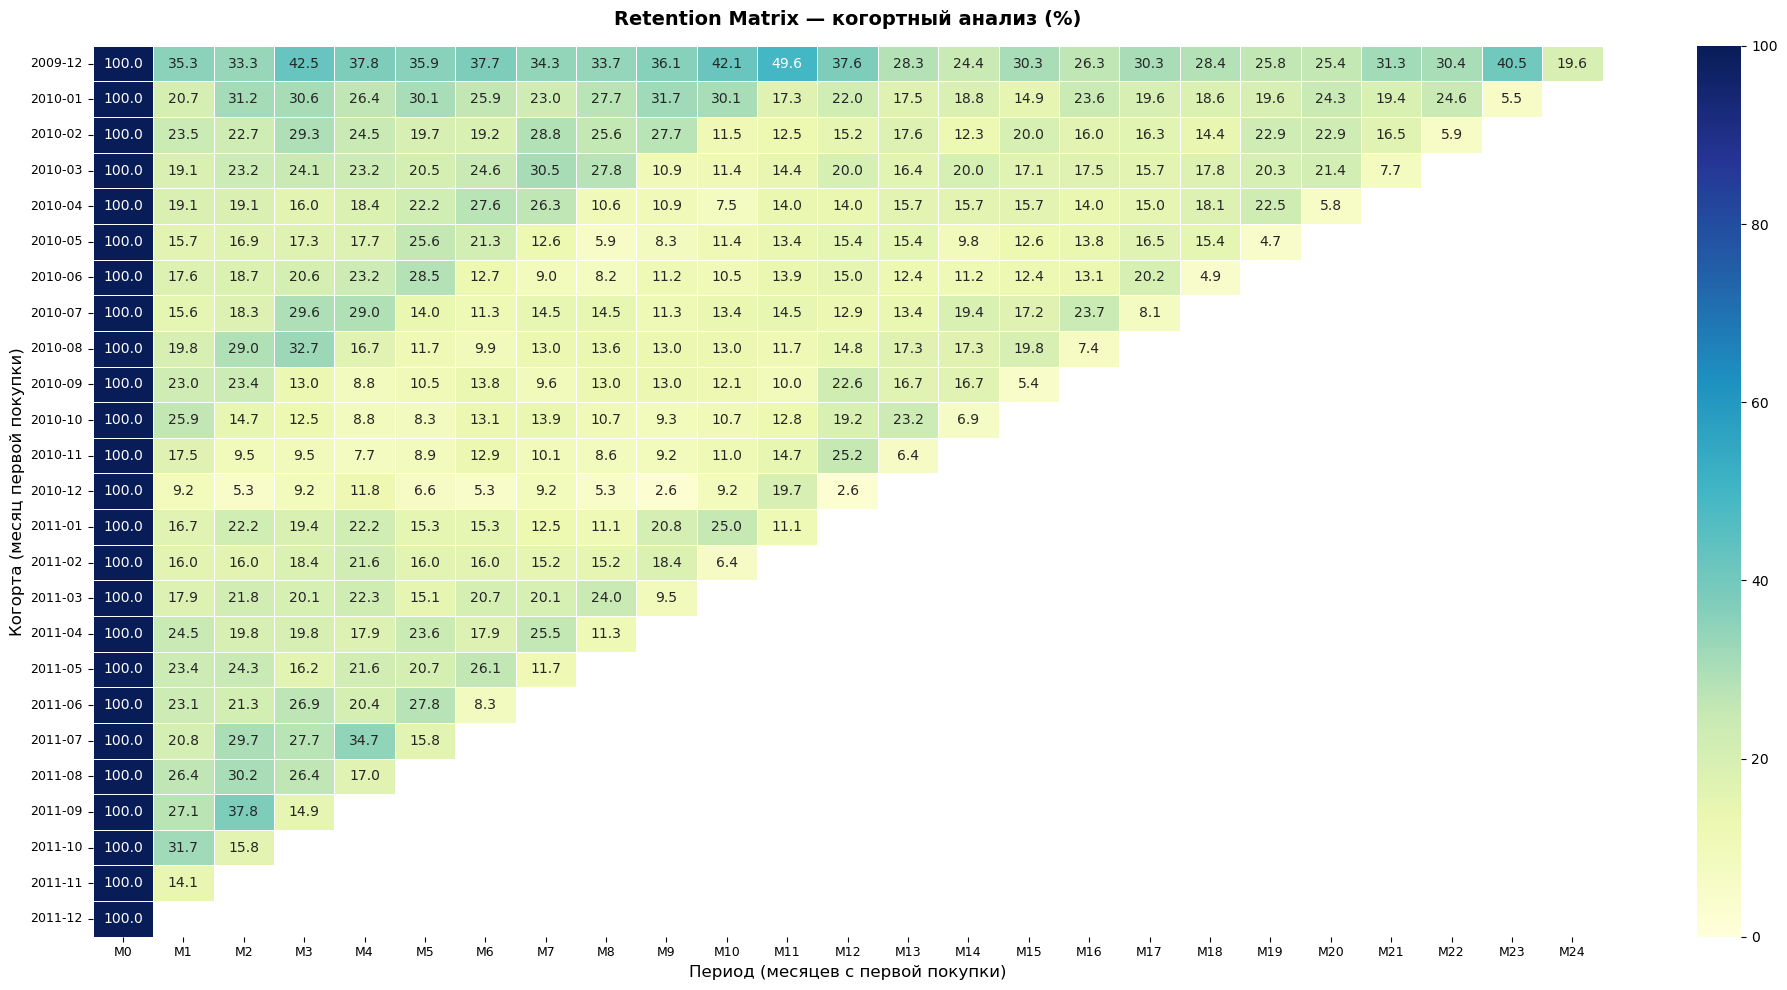

In [9]:
fig, ax = plt.subplots(figsize=(20, 10))

# Строим heatmap через Seaborn
sns.heatmap(
    retention_matrix,
    annot=True,          # показывать числа в ячейках
    fmt='.1f',           # формат чисел — 1 знак после запятой
    cmap='YlGnBu',       # цветовая схема
    vmin=0,              # минимум шкалы
    vmax=100,            # максимум шкалы
    linewidths=0.5,      # границы между ячейками
    ax=ax
)

ax.set_title('Retention Matrix — когортный анализ (%)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Период (месяцев с первой покупки)', fontsize=12)
ax.set_ylabel('Когорта (месяц первой покупки)', fontsize=12)

# Форматируем подписи по оси Y — только год-месяц
ax.set_yticklabels(
    [d.strftime('%Y-%m') for d in retention_matrix.index],
    rotation=0,
    fontsize=9
)

# Форматируем подписи по оси X
ax.set_xticklabels(
    [f'М{int(x)}' for x in retention_matrix.columns],
    rotation=0,
    fontsize=9
)

plt.tight_layout()
#plt.savefig('cohort_retention.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
Ключевые выводы когортного анализа:

1. Критический момент оттока — М1: теряем 65-80% новых клиентов
   после первой покупки
2. Декабрьские когорты самые лояльные — retention 30-40% vs
   10-20% у остальных
3. Сезонный всплеск в М11-М12 — клиенты возвращаются
   к следующему Рождеству
4. После М2 retention стабилизируется — если удержали 2 месяца,
   клиент остаётся надолго